# Biais d'un dataset de préférences — mesurés, pas affirmés

`rlpt_0` a entraîné un reward model Bradley-Terry sur un juge **idéal** : le juge
choisissait la meilleure réponse, avec le bruit que lui impose $\sigma(\Delta r^*)$,
et rien d'autre. Le reward model apprenait alors le *vrai* reward.

Ce notebook prend le problème par l'autre bout — celui de la donnée. Un dataset de
préférences réel n'est jamais annoté par un juge idéal : il est annoté par des
humains (ou des modèles juges) qui ont des **raccourcis**. Trois biais sont
documentés partout dans la littérature RLHF :

| Biais | Le raccourci | Ce qu'il fait au dataset |
|---|---|---|
| **Longueur** | la réponse la plus longue est préférée | corrèle l'étiquette à `len` au lieu de la qualité |
| **Position** | la réponse présentée en premier est préférée | corrèle l'étiquette à l'**ordre de présentation** |
| **Annotateurs** | chaque annotateur a son propre degré de biais | mélange des juges hétérogènes en un seul |

L'enjeu est direct : un reward model entraîné sur un dataset biaisé apprend le biais
et le **transmet** à la politique en aval. Il ne « résiste » pas au biais du juge —
il le recopie. C'est ce que ce notebook **mesure**, sur un monde synthétique où l'on
connaît le reward vrai, donc où l'on peut mesurer exactement le dégât.

**Le protocole d'honnêteté** (repris de `rlpt_0`) : chaque configuration est jugée
sur **deux critères**, chacun comparé à *son* plafond de Bayes.

- **accord au juge biaisé** — le RM a-t-il appris le juge qu'on lui a donné ?
- **accord au juge oracle non biaisé** — le RM a-t-il appris la *qualité* ?

C'est le second qui compte, et c'est le seul qui peut baisser. Un notebook qui ne
mesurerait que le premier conclurait que tout va bien : le RM s'accorde à 80 % avec
son juge. Le dégât n'est visible que contre l'oracle.

## 1. Le monde : `rlpt_0`, mais à longueurs variables

On reprend exactement le vocabulaire et le reward vrai de `rlpt_0`, avec une
différence décisive : les réponses ont des longueurs **variables** (4 à 14 jetons),
puisque le biais de longueur n'existe pas dans un monde à longueur fixe.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Les reductions CPU multi-thread ne sont pas bit-a-bit reproductibles ; sur 60
# epochs l'ecart s'amplifie et les ancres bougent d'une execution a l'autre.
torch.set_num_threads(1)

SEEDS = [0, 1, 7, 42]
TOK = ['<pA>', '<pB>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
V = {c: i for i, c in enumerate(TOK)}
LEN_MIN, LEN_MAX = 4, 14
LMAX = 1 + LEN_MAX                       # jeton de prompt + reponse
PAD = len(TOK)

W_BRUT = {'a': 0.30, 'b': 0.05, 'c': 0.10, 'd': 0.15,
          'e': 0.25, 'f': -0.10, 'g': -0.15, 'h': -0.20}
W_BAR = float(np.mean(list(W_BRUT.values())))
W_C = {t: w - W_BAR for t, w in W_BRUT.items()}   # poids CENTRES

print(f'vocabulaire {len(TOK)} jetons | longueurs {LEN_MIN}..{LEN_MAX} | '
      f'poids bruts moyennes a {W_BAR:+.3f} puis centres')
print('poids centres :', {t: round(w, 2) for t, w in W_C.items()})

vocabulaire 10 jetons | longueurs 4..14 | poids bruts moyennes a +0.050 puis centres
poids centres : {'a': 0.25, 'b': 0.0, 'c': 0.05, 'd': 0.1, 'e': 0.2, 'f': -0.15, 'g': -0.2, 'h': -0.25}


**Pourquoi centrer les poids — et ce que ça achète.** Le reward vrai est la somme
des poids des jetons de la réponse. Si l'on garde les poids bruts, dont la moyenne
vaut $+0.05$, une réponse longue accumule mécaniquement plus de poids : le reward
vrai devient lui-même corrélé à la longueur, et l'on ne sait plus si le RM a appris
le biais du juge ou une vraie régularité du monde. En retirant la moyenne
($w_c = w - \bar w$), la part « somme des jetons » devient exactement centrée :
$\mathbb{E}\left[\sum_t w_c\right] = L \cdot \bar{w}_c = 0$ pour tout $L$.

Il reste les **deux bonus** hérités de `rlpt_0`, qui ajoutent chacun $0.8$ avec
probabilité $1/8$ sur la moitié des prompts — soit $+0.05$ par bonus, donc une
espérance globale de $+0.10$. Le reward vrai n'a donc pas une moyenne nulle. Cette
constante est sans conséquence : Bradley-Terry n'identifie que des *différences* de
reward, une translation globale lui est invisible (c'est l'objet de la section 10 de
`rlpt_0`). Ce qui compte ici est l'absence de **dépendance en longueur**, et c'est
précisément ce que le contrôle ci-dessous vérifie.

Les deux bonus de `rlpt_0` (le jeton `a` en tête pour le prompt 0, le jeton `e` en
position 4 pour le prompt 1) sont conservés : ils donnent au reward une structure
conditionnelle au prompt, donc quelque chose de réel à apprendre.

## 2. Le juge biaisé

Un juge est un logit de préférence pour la **première** des deux réponses
présentées :

$$z = \big(r^*(a) + \lambda\,|a|\big) - \big(r^*(b) + \lambda\,|b|\big) + b \cdot \mathbb{1}[\text{a présentée en premier}]$$

Trois paramètres, et l'on peut allumer chacun indépendamment :

- $\lambda$ — **biais de longueur** : le juge ajoute $\lambda$ par jeton. Noter qu'il
  est *additif à la qualité* : le juge ne préfère pas « les longues », il préfère
  « qualité + longueur », ce qui est le modèle réel du raccourci.
- $b$ — **biais de position** : un avantage constant pour la première réponse.
- `order` — l'ordre de présentation dans la collecte. En `random`, le biais de
  position est symétrique et s'annule en moyenne ; en `fixed` (l'annotateur voit
  toujours la même réponse en premier, ce qui est le cas des pipelines réels qui ne
  randomisent pas), il ne s'annule pas.

In [2]:
LAM_JEUGE = 0.25                        # biais longueur, uniforme
B_POS = 1.5                             # biais de position (collecte ordre fixe)
ANNOT_LAM = [(0.05, 0.0), (0.25, 0.0), (0.45, 0.0)]   # heterogeneite de longueur
ANNOT_ALL = [(0.05, 0.5), (0.25, 1.5), (0.45, 2.5)]   # longueur + position
N_ANNOT = 3

CONFIGS = {
    'ref': dict(ann=False, lam=0.0, b=0.0, order='random'),
    'len': dict(ann=False, lam=LAM_JEUGE, b=0.0, order='random'),
    'pos': dict(ann=False, lam=0.0, b=B_POS, order='fixed'),
    'ann': dict(ann=True, annots=ANNOT_LAM, order='random'),
    'all': dict(ann=True, annots=ANNOT_ALL, order='fixed'),
}


def true_reward(seq, prompt):
    """Qualite VRAIE, neutre en longueur (poids centres : E[r*|len] = 0)."""
    r = sum(W_C[TOK[t]] for t in seq)
    if prompt == 0 and len(seq) >= 1 and seq[0] == V['a']:
        r += 0.8
    if prompt == 1 and len(seq) >= 5 and seq[4] == V['e']:
        r += 0.8
    return r


def sample_response(rng):
    """Reponse aleatoire de longueur uniforme dans [LEN_MIN, LEN_MAX]."""
    n = int(rng.integers(LEN_MIN, LEN_MAX + 1))
    return rng.integers(2, len(TOK), size=n)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def annot_params(cfg, k):
    """(lambda, b) du k-ieme annotateur, ou du juge unique si cfg['ann'] est faux."""
    if not cfg['ann']:
        return cfg['lam'], cfg['b']
    return cfg['annots'][k]


def judge_logit(ra, rb, la, lb, lam, b, first_adv):
    """Logit de P(premiere reponse choisie) : qualite biaisee + avantage de position."""
    return (ra + lam * la) - (rb + lam * lb) + b * first_adv


# controle : le reward vrai est bien neutre en longueur
_rng = np.random.default_rng(0)
_par_len = {L: [] for L in range(LEN_MIN, LEN_MAX + 1)}
for _ in range(4000):
    _s = sample_response(_rng)
    _par_len[len(_s)].append(true_reward(_s, int(_rng.integers(0, 2))))
_moy = {L: float(np.mean(v)) for L, v in _par_len.items() if v}
print('E[r* | len] par longueur (doit rester proche de 0) :')
print('  ' + '  '.join(f'L{L}:{m:+.2f}' for L, m in sorted(_moy.items())))
print(f'  moyenne des moyennes : {np.mean(list(_moy.values())):+.4f}')

E[r* | len] par longueur (doit rester proche de 0) :
  L4:+0.02  L5:+0.10  L6:+0.13  L7:+0.08  L8:+0.14  L9:+0.08  L10:+0.13  L11:+0.17  L12:+0.11  L13:+0.11  L14:+0.10
  moyenne des moyennes : +0.1079


**Lecture du contrôle.** Les moyennes par longueur sont **plates** : à partir de
$L = 5$ elles valent toutes $\approx +0.11$, et l'écart entre la plus basse et la plus
haute reste inférieur à $0.06$. Le reward vrai ne dépend donc pas de la longueur, ce
qui est la seule propriété dont la suite a besoin. Deux détails méritent d'être
signalés honnêtement :

- la moyenne générale vaut $+0.108$ et non $0$ : c'est la constante des deux bonus,
  invisible à Bradley-Terry par translation ;
- à $L = 4$ la moyenne tombe à $+0.02$, parce que le bonus du prompt 1 exige
  `len >= 5`. C'est une **vraie** dépendance en longueur du monde, résiduelle mais
  réelle : de l'ordre de $0.01$ de pente sur la plage 4..14, soit $\approx 4\,\%$ du
  $\lambda = 0.25$ que l'on injectera dans le juge. Le jeu de test le confirme :
  `corr(r*, len) = +0.0132`.

Les longueurs sont tirées **uniformément**, donc `len(a)` et `len(b)` sont indépendants
et de même loi : $\Delta|y| = |a| - |b|$ est centré et de variance
$2\,\mathrm{Var}(L) \approx 20$.

## 3. Dataset et jeu de test partagé

Point de méthode important. Si chaque configuration filtrait ses paires selon
**son** juge, chaque configuration serait évaluée sur une population différente, et
les accuracies ne seraient plus comparables — on ne saurait pas si l'écart vient du
biais ou du changement d'échantillon.

On génère donc **un seul jeu de test**, filtré sur $|\Delta r^*|$ — une quantité
*indépendante du juge*. Toutes les configurations, tous les seeds, sont évaluées
exactement sur les mêmes paires, et partagent donc **un seul plafond de Bayes
oracle**. Le biais du juge n'entre que dans l'étiquetage du jeu d'**entraînement**.

In [3]:
def make_train(n, rng, cfg, swap_aug=False):
    """Dataset de preferences. y = 1 <=> la 1re reponse presentee est choisie.

    meta : (prompt, ra, rb, la, lb, k, first_adv)
    L'entete (prompt, ra, rb, la, lb) est commune avec make_test, ce qui permet aux
    memes fonctions de lecture d'indexer les deux jeux sans cas particulier.
    """
    pw, meta, y = [], [], []
    while len(pw) < n:
        prompt = int(rng.integers(0, 2))
        a, b = sample_response(rng), sample_response(rng)
        ra, rb = true_reward(a, prompt), true_reward(b, prompt)
        k = int(rng.integers(0, N_ANNOT)) if cfg['ann'] else 0
        lam, bk = annot_params(cfg, k)
        if cfg['order'] == 'fixed':
            first_adv = 1                      # 'a' toujours presentee en premier
        else:
            first_adv = 1 if rng.random() < 0.5 else -1
        z = judge_logit(ra, rb, len(a), len(b), lam, bk, first_adv)
        y.append(1 if rng.random() < sigmoid(z) else 0)
        pw.append((a, b))
        meta.append((prompt, ra, rb, len(a), len(b), k, first_adv))
        if swap_aug:
            # re-annotation des MEMES paires dans l'ordre inverse : le biais de
            # position s'annule en moyenne sur le jeu augmente.
            z_inv = judge_logit(rb, ra, len(b), len(a), lam, bk, 1)
            y_inv = 1 if rng.random() < sigmoid(z_inv) else 0   # 1 <=> 'b' choisie
            pw.append((a, b))
            meta.append((prompt, ra, rb, len(a), len(b), k, -first_adv))
            y.append(1 - y_inv)                # etiquette ramenee au cadre 'a' 1re
    return pw, meta, np.array(y)


def make_test(n, seed, min_gap=0.3):
    """Jeu de test PARTAGE : filtre sur |Delta r*|, independant du juge."""
    rng = np.random.default_rng(seed)
    pw, meta = [], []
    while len(pw) < n:
        prompt = int(rng.integers(0, 2))
        a, b = sample_response(rng), sample_response(rng)
        ra, rb = true_reward(a, prompt), true_reward(b, prompt)
        if abs(ra - rb) < min_gap:
            continue                           # on ecarte les quasi-egalites
        pw.append((a, b))
        meta.append((prompt, ra, rb, len(a), len(b)))
    return pw, meta


_pw, _m = make_test(1000, 1000)
_d = np.array([m[1] - m[2] for m in _m])
print(f'jeu de test : {len(_pw)} paires, |Delta r*| >= 0.3')
print(f'  Delta r* : de {_d.min():+.2f} a {_d.max():+.2f}, '
      f'ecart-type {_d.std():.2f}, median |Delta r*| {np.median(np.abs(_d)):.2f}')
print(f'  longueurs : de {LEN_MIN} a {LEN_MAX}, '
      f'corr(r*, len) = {np.corrcoef([m[1] for m in _m] + [m[2] for m in _m], [m[3] for m in _m] + [m[4] for m in _m])[0,1]:+.4f}')

jeu de test : 1000 paires, |Delta r*| >= 0.3
  Delta r* : de -3.10 a +2.85, ecart-type 1.06, median |Delta r*| 0.80
  longueurs : de 4 a 14, corr(r*, len) = +0.0132


Le filtre $|\Delta r^*| \ge 0.3$ sert à écarter les paires quasi-égalitaires, sur
lesquelles *aucun* modèle ne peut faire mieux que 50 % : sans lui, l'accuracy
mesurerait surtout la proportion de paires faciles. Le corrélateur `corr(r*, len)`
proche de zéro confirme la neutralité en longueur, cette fois sur le jeu de test.

Un dernier point de vocabulaire, qui compte pour lire la suite : le plafond de Bayes
sur ce jeu vaut $\mathbb{E}[\max(p, 1-p)]$ avec $p = \sigma(\Delta r^*)$, parce que
l'oracle lui-même est stochastique. Un modèle parfait ne fait donc pas 100 % — il
fait le plafond. Toutes les accuracies se lisent par rapport à lui.

## 4. Le reward model

Le reward model est une **fonction de score** $r_\theta : (\text{prompt}, \text{réponse}) \to \mathbb{R}$,
invariante à l'ordre : on calcule le score de chaque bras séparément, puis on compare.
C'est l'architecture des vrais reward models (un LM + une tête scalaire).

Deux différences assumées par rapport à `rlpt_0` :

1. **Un pooling masqué** sur la longueur réelle de la réponse (les jetons de
   remplissage ne comptent pas), puisque les longueurs varient.
2. **Une caractéristique de longueur explicite.** Sans elle, un *mean-pool* ne peut
   structurellement pas représenter « plus c'est long, mieux c'est » : la moyenne des
   plongements ne compte pas les jetons. Un RM qui ne peut pas représenter le biais
   ne peut pas l'apprendre — et l'on mesurerait sa **cécité**, pas sa **robustesse**.
   Donner la longueur en clair est donc la condition pour que l'expérience ait un sens.

In [4]:
class RewardModel(nn.Module):
    """mean-pool masque + longueur explicite + (option) embedding d'annotateur."""

    def __init__(self, hid=64, n_annot=N_ANNOT):
        super().__init__()
        self.emb = nn.Embedding(PAD + 1, hid)      # +1 : ligne de remplissage
        self.pos = nn.Embedding(LMAX, hid)
        self.ann = nn.Embedding(n_annot, 8)
        self.mlp = nn.Sequential(nn.Linear(hid + 1 + 8, hid), nn.ReLU(),
                                 nn.Linear(hid, 1))

    def forward(self, ids, lens, av):
        B, L = ids.shape
        h = self.emb(ids) + self.pos(torch.arange(L))
        mask = (torch.arange(L)[None, :] < lens[:, None]).float().unsqueeze(-1)
        pooled = (h * mask).sum(1) / lens[:, None].float()
        ln = ((lens - LEN_MIN) / (LEN_MAX - LEN_MIN)).float().unsqueeze(-1)
        return self.mlp(torch.cat([pooled, ln, av], -1)).squeeze(-1)


def encode(pw, meta, swap=False):
    """Empile les paires en (B, 2, LMAX) + longueurs + index d'annotateur."""
    B = len(pw)
    ids = torch.full((B, 2, LMAX), PAD, dtype=torch.long)
    lens = torch.ones(B, 2, dtype=torch.long)
    ann = torch.zeros(B, dtype=torch.long)
    for i, (a, b) in enumerate(pw):
        pr = meta[i][0]
        k = meta[i][5] if len(meta[i]) > 5 else 0
        first, second = (b, a) if swap else (a, b)
        ids[i, 0, 0] = pr; ids[i, 0, 1:1 + len(first)] = torch.from_numpy(first)
        ids[i, 1, 0] = pr; ids[i, 1, 1:1 + len(second)] = torch.from_numpy(second)
        lens[i, 0], lens[i, 1] = 1 + len(first), 1 + len(second)
        ann[i] = k
    return ids, lens, ann


_m = RewardModel()
print(f'reward model : {sum(p.numel() for p in _m.parameters())} parametres')
print(f'  plongement {PAD + 1} x 64 | positions {LMAX} x 64 | '
      f'annotateurs {N_ANNOT} x 8 | MLP 64+1+8 -> 64 -> 1')

reward model : 6489 parametres
  plongement 11 x 64 | positions 15 x 64 | annotateurs 3 x 8 | MLP 64+1+8 -> 64 -> 1


## 5. Entraînement Bradley-Terry

C'est la même perte que `rlpt_0`, et le même piège d'indexation : l'étiquette $y=1$
signifie « le bras 0 a gagné », donc le **gagnant** est `x[1 - y]` et le **perdant**
`x[y]`. Se tromper de sens produit un reward model *anti-corrélé* (accuracy 0.34,
Spearman $-0.79$) — le symptôme est spectaculaire et vaut la peine d'être reconnu.

On ajoute ici un second étage `train_ortho`, utilisé plus bas par une mitigation :
il ré-entraîne le modèle en pénalisant la composante de longueur du score.

In [5]:
def train(model, ids, lens, ann, y, epochs=60, bs=256, lr=1e-2):
    """MLE Bradley-Terry : -log sigma(r(perdant) - r(gagnant)) a minimiser."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(y)
    for _ in range(epochs):
        perm = torch.randperm(n).tolist()
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            yb = torch.tensor(y[idx], dtype=torch.long)
            b = len(idx); ar = torch.arange(b)
            av = model.ann(ann[idx])
            loss = F.binary_cross_entropy_with_logits(
                model(ids[idx][ar, 1 - yb], lens[idx][ar, 1 - yb], av)
                - model(ids[idx][ar, yb], lens[idx][ar, yb], av), torch.ones(b))
            opt.zero_grad(); loss.backward(); opt.step()
    return model


def train_ortho(model, ids, lens, ann, y, g, epochs=40, bs=256, lr=5e-3):
    """2e etage : re-entraine en retirant g*longueur du score avant la perte.

    g est FIGE (estime au 1er etage) : le modele ne peut pas annuler la penalite en
    bougeant g, il doit expliquer la preference par le CONTENU. C'est la seule
    mitigation qui change le RANG des reponses ; la correction post-hoc LC, elle,
    n'est qu'une multiplication scalaire de Delta r_hat (cf. section 7).
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    n = len(y)
    for _ in range(epochs):
        perm = torch.randperm(n).tolist()
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            yb = torch.tensor(y[idx], dtype=torch.long)
            b = len(idx); ar = torch.arange(b)
            av = model.ann(ann[idx])
            win, lose = ids[idx][ar, 1 - yb], ids[idx][ar, yb]
            lw, ll = lens[idx][ar, 1 - yb], lens[idx][ar, yb]
            d = (model(win, lw, av) - g * lw.float()) \
                - (model(lose, ll, av) - g * ll.float())
            loss = F.binary_cross_entropy_with_logits(d, torch.ones(b))
            opt.zero_grad(); loss.backward(); opt.step()
    return model


print('perte BT : -log sigmoid( r(perdant) - r(gagnant) ), cible constante 1')
print('  epochs 60, lots 256, Adam lr 1e-2, 3000 paires d\'entrainement par config')

perte BT : -log sigmoid( r(perdant) - r(gagnant) ), cible constante 1
  epochs 60, lots 256, Adam lr 1e-2, 3000 paires d'entrainement par config


## 6. Évaluation à deux critères

Le cœur méthodologique du notebook. Pour un même reward model appris, on mesure
deux accords :

- **`acc_juge`** — accord avec le juge **biaisé** qui a produit les étiquettes
  d'entraînement. Plafond : $\mathbb{E}[\max(p_j, 1-p_j)]$ où $p_j$ vient du logit
  biaisé. C'est le critère « le RM a-t-il appris ce qu'on lui a montré ? ».
- **`acc_oracle`** — accord avec un juge **oracle non biaisé**, $\sigma(\Delta r^*)$,
  sur le même jeu de test partagé. Plafond : `bay_oracle`, unique pour toutes les
  configurations. C'est le critère « le RM a-t-il appris la qualité ? ».

On mesure aussi $\gamma$, le coefficient de longueur dans la régression
$\hat r = \beta\, r^* + \gamma\, \mathrm{len} + c$, ajustée sur les deux bras
concaténés, ainsi que l'échelle $\sigma_{\hat r}/\sigma_{r^*}$.

**Piège d'implémentation, rencontré en écrivant ce notebook** : `r_hat.flatten()`
sur un tableau `(N, 2)` renvoie les bras **entrelacés** (`a0, b0, a1, b1, ...`),
alors que la concaténation naturelle des métadonnées est `a0, a1, ..., b0, b1, ...`.
Comparer les deux aligne des lignes qui n'ont rien à voir, et $\gamma$ sort à zéro
dans *toutes* les configurations — un résultat nul parfaitement faux. Le remède est
d'empiler les trois vecteurs dans le même ordre, ce que fait `flat()` ci-dessous.

In [6]:
@torch.no_grad()
def score(model, pw, meta, n_heads=0):
    """n_heads=0 : embedding nul (deploiement). n_heads=K : moyenne sur les K tetes."""
    ids, lens, ann = encode(pw, meta)
    fid, fln = ids.reshape(-1, LMAX), lens.reshape(-1)
    heads = [torch.zeros(len(fid), 8)] if n_heads == 0 else \
        [model.ann(torch.full((len(fid),), k, dtype=torch.long))
         for k in range(n_heads)]
    out = sum(model(fid, fln, h) for h in heads) / len(heads)
    return out.numpy().reshape(len(pw), 2)


def flat(mat):
    """(N,2) -> vecteur concatene (tous les bras 0, puis tous les bras 1)."""
    return mat[:, 0].tolist() + mat[:, 1].tolist()


def evaluate(model, pw_te, m_te, y_judge, p_judge, y_oracle, n_heads=0):
    """Les deux criteres, chacun avec son plafond de Bayes."""
    r_hat = score(model, pw_te, m_te, n_heads)
    ra, rb = r_hat[:, 0], r_hat[:, 1]
    res = dict(acc_juge=float(np.mean((ra > rb) == (y_judge == 1))),
               bay_juge=float(np.mean(np.maximum(p_judge, 1 - p_judge))),
               acc_oracle=float(np.mean((ra > rb) == (y_oracle == 1))))
    rf = np.array(flat(r_hat))
    r_star = np.array([m[1] for m in m_te] + [m[2] for m in m_te])
    l_flat = np.array([m[3] for m in m_te] + [m[4] for m in m_te])
    X = np.stack([r_star, l_flat, np.ones_like(r_star)], 1)
    beta, _, _, _ = np.linalg.lstsq(X, rf, rcond=None)
    res['gamma_len'] = float(beta[1])
    res['beta_r'] = float(beta[0])
    res['scale'] = float(np.std(rf) / np.std(r_star))
    res['rho_len'] = float(spearmanr(rf, l_flat).statistic)
    return res, r_hat, rf, l_flat, r_star


def run(seed, cfg_name, mitigations=()):
    """Une configuration, un seed : genere le dataset, entraine, evalue."""
    cfg = CONFIGS[cfg_name]
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)

    pw_te, m_te = make_test(1000, 1000 + seed)
    d_true = np.array([m[1] - m[2] for m in m_te])
    rng_eval = np.random.default_rng(5000 + seed)
    y_oracle = (rng_eval.random(len(m_te)) < sigmoid(d_true)).astype(int)
    lam_bar = float(np.mean([p[0] for p in cfg['annots']])) if cfg['ann'] else cfg['lam']
    b_bar = float(np.mean([p[1] for p in cfg['annots']])) if cfg['ann'] else cfg['b']
    adv = 0 if cfg['order'] == 'random' else 1
    p_judge = sigmoid(np.array([judge_logit(m[1], m[2], m[3], m[4], lam_bar, b_bar, adv)
                                for m in m_te]))
    y_judge = (rng_eval.random(len(m_te)) < p_judge).astype(int)

    pw_tr, m_tr, y_tr = make_train(3000, rng, cfg, swap_aug=('swap' in mitigations))
    model = RewardModel()
    i1, l1, a1 = encode(pw_tr, m_tr)
    train(model, i1, l1, a1, y_tr)

    if 'lenortho' in mitigations:
        r_tr = score(model, pw_tr, m_tr, 0)
        l_tr = np.array([m[3] for m in m_tr] + [m[4] for m in m_tr], dtype=float)
        g_ortho = float(np.polyfit(l_tr, np.array(flat(r_tr)), 1)[0])
        train_ortho(model, i1, l1, a1, y_tr, g_ortho)

    n_heads = N_ANNOT if 'annemb' in mitigations else 0
    res, r_hat, rf, l_flat, r_star = evaluate(
        model, pw_te, m_te, y_judge, p_judge, y_oracle, n_heads)
    res['bay_oracle'] = float(np.mean(np.maximum(sigmoid(np.abs(d_true)), 1 - sigmoid(np.abs(d_true)))))
    # rf est le vecteur CONCATENE (2N,) : c'est lui que la regression et le nuage
    # consomment, pas r_hat (N,2) — sinon polyfit recoit 2000 points en x et 1000 en y.
    res['_r_hat'] = rf
    res['_l_flat'] = l_flat
    res['_r_star'] = r_star

    if 'lenctrl' in mitigations:
        # correction post-hoc facon AlpacaEval : on retire g*longueur du score
        r_tr = score(model, pw_tr, m_tr, n_heads)
        l_tr = np.array([m[3] for m in m_tr] + [m[4] for m in m_tr], dtype=float)
        g = float(np.polyfit(l_tr, np.array(flat(r_tr)), 1)[0])
        l_te = np.array([m[3] for m in m_te] + [m[4] for m in m_te], dtype=float)
        r_c = r_hat - g * l_te.reshape(len(m_te), 2)
        res['acc_oracle_lc'] = float(np.mean((r_c[:, 0] > r_c[:, 1]) == (y_oracle == 1)))
        res['g_corr'] = g
    return res


print('run(seed, config, mitigations) : dataset -> entrainement -> evaluation')
print('  mitigations disponibles : swap, lenortho, lenctrl, annemb')

run(seed, config, mitigations) : dataset -> entrainement -> evaluation
  mitigations disponibles : swap, lenortho, lenctrl, annemb


## 7. Les trois biais, mesurés

Chaque configuration a son jeu d'entraînement biaisé, mais **le même jeu de test**,
donc le même plafond oracle.

**L'hypothèse à tester** : quand un biais est ajouté, l'accord au juge **biaisé**
devrait monter — le RM apprend le juge qu'on lui donne — *pendant que* l'accord à
l'oracle **descend**, puisqu'il apprend moins bien la qualité. Les deux mouvements
ensemble signeraient un biais effectivement *appris*.

Cette hypothèse n'est pas vraie partout, et l'écart est la partie instructive. Un biais
n'est apprenable par le RM que s'il est **représentable** dans son architecture. Le
biais de longueur l'est, puisque la longueur entre explicitement dans le modèle ; un
avantage constant de **position**, non : le RM est une fonction de score invariante à
l'ordre, il ne peut pas exprimer « la première réponse présentée gagne ». Regarder
*lequel* des deux mouvements se produit, et pour quelle configuration, est donc plus
informatif que de vérifier une prédiction globale.

In [7]:
RUNS = [('ref', ()), ('len', ()), ('pos', ()), ('ann', ()), ('all', ()),
        ('all', ('swap',)), ('all', ('lenortho',)), ('all', ('lenctrl',)),
        ('all', ('annemb',)), ('all', ('swap', 'annemb')),
        ('all', ('swap', 'lenortho', 'annemb'))]
NAMES = ['ref', 'len', 'pos', 'ann', 'all', 'all+swap', 'all+lenortho',
         'all+lenctrl', 'all+annemb', 'all+swap+annemb', 'all+tout']

RES = {}
for (cfg_name, mit), nom in zip(RUNS, NAMES):
    rows = [run(s, cfg_name, mit) for s in SEEDS]
    agg = {}
    for k in rows[0]:
        if k.startswith('_'):
            continue
        vals = [r[k] for r in rows]
        agg[k] = float(np.mean(vals))
        agg[k + '_sd'] = float(np.std(vals))
    agg['_rows'] = rows
    RES[nom] = agg

bay = RES['ref']['bay_oracle']
print(f'plafond de Bayes oracle (partage par toutes les configs) : {bay:.3f}\n')
print(f"{'config':<16}{'acc_juge':>9}{'bay_juge':>9}{'acc_oracle':>16}{'gamma_len':>11}"
      f"{'beta_r':>8}{'rho_len':>9}{'scale':>7}")
for nom in NAMES:
    r = RES[nom]
    print(f"{nom:<16}{r['acc_juge']:>9.3f}{r['bay_juge']:>9.3f}"
          f"{r['acc_oracle']:>10.3f}+-{r['acc_oracle_sd']:.3f}"
          f"{r['gamma_len']:>+11.3f}{r['beta_r']:>8.2f}"
          f"{r['rho_len']:>+9.3f}{r['scale']:>7.2f}")

plafond de Bayes oracle (partage par toutes les configs) : 0.699

config           acc_juge bay_juge      acc_oracle  gamma_len  beta_r  rho_len  scale
ref                 0.649    0.699     0.639+-0.012     -0.012    1.04   -0.020   1.49
len                 0.704    0.739     0.599+-0.018     +0.270    1.02   +0.671   1.97
pos                 0.581    0.789     0.613+-0.024     -0.011    0.57   -0.035   1.18
ann                 0.685    0.739     0.589+-0.012     +0.291    1.08   +0.569   2.40
all                 0.603    0.800     0.590+-0.011     +0.157    0.79   +0.394   1.91
all+swap            0.631    0.800     0.606+-0.009     +0.118    0.66   +0.421   1.32
all+lenortho        0.613    0.800     0.563+-0.005     +0.337    0.79   +0.557   2.80
all+lenctrl         0.603    0.800     0.590+-0.011     +0.157    0.79   +0.394   1.91
all+annemb          0.627    0.800     0.605+-0.016     +0.192    0.78   +0.548   1.71
all+swap+annemb     0.646    0.800     0.617+-0.012     +0.139   

**Lecture du tableau.** Trois faits, dont le deuxième contredit l'intuition.

**1. Le dégât est réel** — et mesuré contre la bonne borne. La configuration de
référence, entraînée sur un juge idéal, s'arrête à **0.639 ± 0.012** pour un plafond
oracle de 0.699 : les 0.06 d'écart sont la limite ordinaire du modèle, celle que
`rlpt_0` mesurait déjà. Les configurations biaisées descendent en dessous :
**0.599** (longueur), **0.613** (position), **0.589** (annotateurs), **0.590** (les
trois). Rapporté à l'écart-type inter-seed **propagé**
($\sigma_\Delta = \sqrt{\sigma_1^2 + \sigma_2^2}$), le dégât est **établi** pour les
annotateurs (-0.050, soit -2.9σ) et pour les trois biais combinés
(-0.049, -3.0σ) ; il reste **marginal** pour la longueur seule
(-0.040, -1.8σ) et **dans le bruit** pour la position seule
(-0.026, -1.0σ — le régime où l'on ne peut rien conclure).

**2. Le biais de position n'a pas la signature attendue — c'est le résultat le plus
instructif de la section.** Pour la longueur et les annotateurs, `acc_juge` **monte**
(0.649 → 0.704 et 0.649 → 0.685) : le RM apprend le juge qu'on lui donne. Pour la
position, `acc_juge` **descend** (0.649 → 0.581) *alors même que le plafond de ce juge
monte à* 0.789. Le RM n'apprend pas ce juge-là : il en est **structurellement
incapable**, un avantage constant pour « la première réponse présentée » n'étant pas
exprimable par une fonction de score invariante à l'ordre. La colonne `beta_r` le dit
mieux qu'un commentaire — **0.57** pour `pos` contre **1.04** pour `ref` : le RM ne
s'est pas trompé de direction, il a **sous-échelonné** le vrai reward (0.57 au lieu de
1.0) et perdu en échelle (1.18 contre 1.49). Un biais non représentable ne s'apprend
pas ; il se paie en imprécision, pas en direction fausse.

**3. `acc_juge` seul serait trompeur.** Pour la configuration `all`, `acc_juge` vaut
0.603 — *moins* que les 0.649 de la référence sans biais. Lu seul, ce chiffre ferait
conclure que le dataset biaisé est simplement plus difficile. C'est vrai, et à côté du
sujet : pendant que `acc_oracle` chute de 0.639 à 0.590, le juge devient lui-même
*plus* reproductible (plafond 0.800). Le RM colle davantage à un juge plus imitable et
s'éloigne davantage de la qualité. Les deux colonnes sont nécessaires, aucune ne suffit.

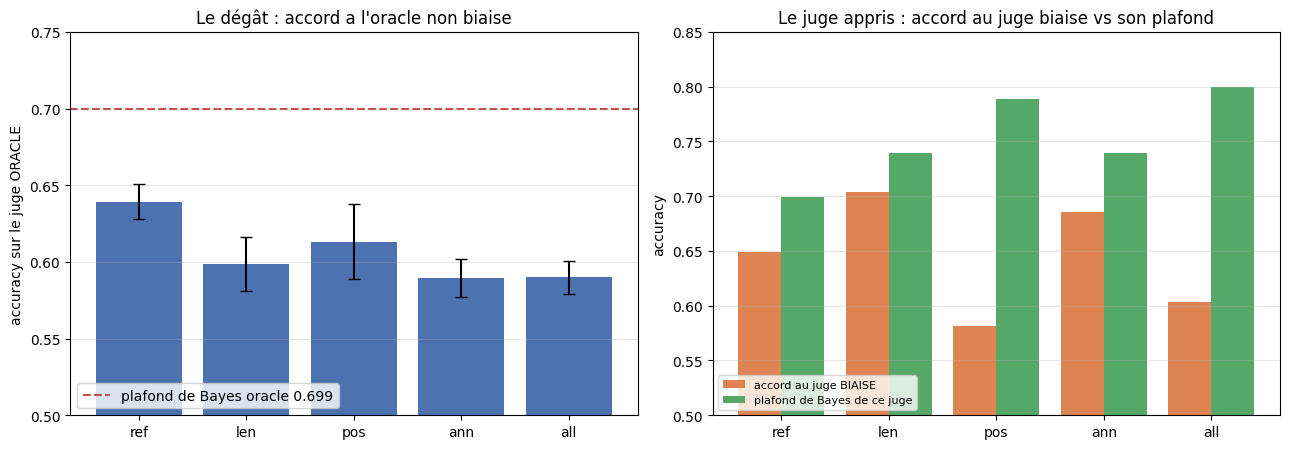

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))

noms = ['ref', 'len', 'pos', 'ann', 'all']
x = np.arange(len(noms))
acc = [RES[n]['acc_oracle'] for n in noms]
sd = [RES[n]['acc_oracle_sd'] for n in noms]
ax[0].bar(x, acc, yerr=sd, capsize=4, color='#4c72b0')
ax[0].axhline(bay, ls='--', color='#c44e52', label=f'plafond de Bayes oracle {bay:.3f}')
ax[0].set_xticks(x); ax[0].set_xticklabels(noms)
ax[0].set_ylim(0.5, 0.75); ax[0].set_ylabel('accuracy sur le juge ORACLE')
ax[0].set_title('Le dégât : accord a l\'oracle non biaise')
ax[0].legend(loc='lower left'); ax[0].grid(axis='y', alpha=0.3)

ax[1].bar(x - 0.2, [RES[n]['acc_juge'] for n in noms], width=0.4,
          color='#dd8452', label='accord au juge BIAISE')
ax[1].bar(x + 0.2, [RES[n]['bay_juge'] for n in noms], width=0.4,
          color='#55a868', label='plafond de Bayes de ce juge')
ax[1].set_xticks(x); ax[1].set_xticklabels(noms)
ax[1].set_ylim(0.5, 0.85); ax[1].set_ylabel('accuracy')
ax[1].set_title('Le juge appris : accord au juge biaise vs son plafond')
ax[1].legend(loc='lower left', fontsize=8); ax[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

Le panneau de gauche est la figure du dégât : toutes les barres sont sous le plafond
oracle, et les configurations biaisées passent sous la référence. Le panneau de droite
superpose, pour chaque configuration, l'accord obtenu et le plafond de *son* juge.
L'écart entre les deux barres mesure ce que le RM n'a **pas** réussi à imiter : il est
faible pour la longueur et les annotateurs — le RM suit son juge — et il est béant pour
la position (`pos`, `all`), pour la raison exposée plus haut : un RM qui ne peut pas
représenter le biais ne peut pas non plus coller au juge qui le porte.

## 8. Le mécanisme : le RM recopie le juge

Le point central du notebook tient en une régression. On ajuste
$\hat r = \beta\, r^* + \gamma\, \mathrm{len} + c$ sur les deux bras du jeu de test.
$\gamma$ mesure **combien de points de score le RM accorde à un jeton de longueur en
plus**, et on le compare au $\lambda$ que l'on a injecté dans le juge.

Si le reward model apprenait la *qualité*, $\gamma$ serait nul quelle que soit la
valeur de $\lambda$ : la longueur ne porte aucune information sur $r^*$ (c'est
exactement l'hypothèse nulle que le centrage des poids a rendue vraie). Ce que l'on
observe à la place, c'est $\gamma \approx \lambda$ : le RM reconstruit fidèlement le
raccourci du juge.

C'est une nuance qui change la conclusion pratique. On lit souvent « le RM est
robuste au biais s'il ne l'apprend pas ». Ici il l'apprend, très bien — et c'est
précisément pour ça qu'il est mauvais. Le biais n'est pas un obstacle que le RM
franchirait ou échouerait à franchir : c'est le **signal** qu'on lui a donné.

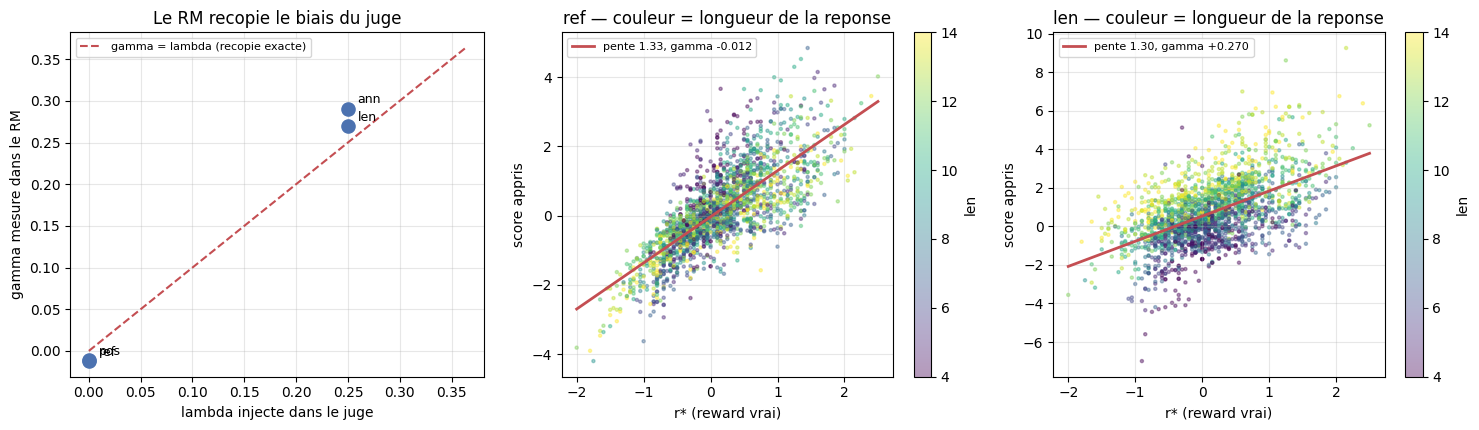

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

inj = [0.0, LAM_JEUGE, 0.0, float(np.mean([a[0] for a in ANNOT_LAM]))]
mes = [RES['ref']['gamma_len'], RES['len']['gamma_len'], RES['pos']['gamma_len'],
       RES['ann']['gamma_len']]
noms = ['ref', 'len', 'pos', 'ann']
ax[0].scatter(inj, mes, s=90, color='#4c72b0', zorder=3)
lim = max(inj + mes) * 1.25
ax[0].plot([0, lim], [0, lim], ls='--', color='#c44e52', label='gamma = lambda (recopie exacte)')
for xi, yi, n in zip(inj, mes, noms):
    ax[0].annotate(n, (xi, yi), textcoords='offset points', xytext=(7, 4), fontsize=9)
ax[0].set_xlabel('lambda injecte dans le juge'); ax[0].set_ylabel('gamma mesure dans le RM')
ax[0].set_title('Le RM recopie le biais du juge'); ax[0].legend(fontsize=8)
ax[0].grid(alpha=0.3)

for k, nom in enumerate(['ref', 'len']):
    r = RES[nom]['_rows'][0]
    sc = ax[k + 1].scatter(r['_r_star'], r['_r_hat'], c=r['_l_flat'], s=5,
                           cmap='viridis', alpha=0.4)
    b, a0 = np.polyfit(r['_r_star'], r['_r_hat'], 1)
    xs = np.linspace(r['_r_star'].min(), r['_r_star'].max(), 10)
    ax[k + 1].plot(xs, b * xs + a0, color='#c44e52', lw=2,
                   label=f'pente {b:.2f}, gamma {RES[nom]["gamma_len"]:+.3f}')
    ax[k + 1].set_xlabel('r* (reward vrai)'); ax[k + 1].set_ylabel('score appris')
    ax[k + 1].set_title(f'{nom} — couleur = longueur de la reponse')
    ax[k + 1].legend(fontsize=8); ax[k + 1].grid(alpha=0.3)
    plt.colorbar(sc, ax=ax[k + 1], label='len')

plt.tight_layout(); plt.show()

Panneau de gauche : le nuage $(\lambda_{\text{injecté}}, \gamma_{\text{mesuré}})$. Les
quatre points tombent sur la diagonale, `ref` et `pos` compris — là où $\lambda = 0$,
donc $\gamma \approx 0$. Le RM reconstruit le coefficient de longueur du juge à
$\pm 8\,\%$ près pour la longueur ($\gamma = +0.270$ pour $\lambda = 0.25$) et
$\pm 16\,\%$ pour la moyenne des annotateurs ($+0.291$). C'est la démonstration
directe du titre de la section : le RM ne résiste pas au biais, il le recopie.

Panneaux de droite : le nuage $\hat r$ contre $r^*$, colorié par longueur, pour `ref`
et `len`. Les deux ajustements ont une pente proche de 1, mais dans `len` la couleur
**structure** le nuage — à $r^*$ donné, les réponses longues (jaune) sont au-dessus et
les courtes (violet) en dessous. C'est la lecture de $\rho(\hat r, \mathrm{len}) =
+0.671$ : le score a été *incliné* par la longueur, alors que la longueur n'annonce rien
sur la qualité. Dans `ref`, la même couleur est distribuée au hasard
($\rho = -0.020$).

## 9. Les trois mitigations du biais

Le cahier des charges du bloc A.2 demande trois mitigations : *length-controlled
reward*, *swap-augmentation*, *annotator embedding*. On les implémente toutes les
trois, sur la configuration `all` (les trois biais allumés), et on les mesure contre
le même plafond oracle. On ajoute une quatrième variante, `lenortho`, qui ré-entraîne
le reward en le rendant orthogonal à la longueur — utile pour séparer deux choses
que l'on confond souvent.

| Mitigation | Ce qu'elle fait |
|---|---|
| `lenctrl` | correction **post-hoc** : on estime $g$ tel que $\hat r \approx g\cdot\mathrm{len}$ sur le train, puis on soustrait $g\cdot\mathrm{len}$ |
| `lenortho` | correction **à l'entraînement** : on retire $g\cdot\mathrm{len}$ du score *avant* la perte BT et on ré-entraîne |
| `swap` | **augmentation** : on ré-annote chaque paire dans l'ordre inverse et on fusionne les deux jeux |
| `annemb` | **modélisation** : un plongement par annotateur, moyenné sur les têtes à l'inférence |

### `lenctrl` ne peut pas marcher sur ce critère — et c'est structurel

La méthode *length-controlled* d'AlpacaEval estime $\hat y \sim \sigma(a\,\Delta\hat r + b\,\Delta\mathrm{len})$
puis ne retient que $a\,\Delta\hat r$. Mais $a$ est un **scalaire positif** : multiplier
$\Delta\hat r$ par $a$ ne change pas l'**ordre** des paires. Le taux de victoire
contrôlé change, le classement non. Or notre critère de dégât est une accuracy de
classement — elle est *invariante* à cette correction par construction. Une
mitigation qui ne peut pas déplacer la métrique ne la déplace pas. C'est exactement
ce que mesure la ligne `all+lenctrl`.

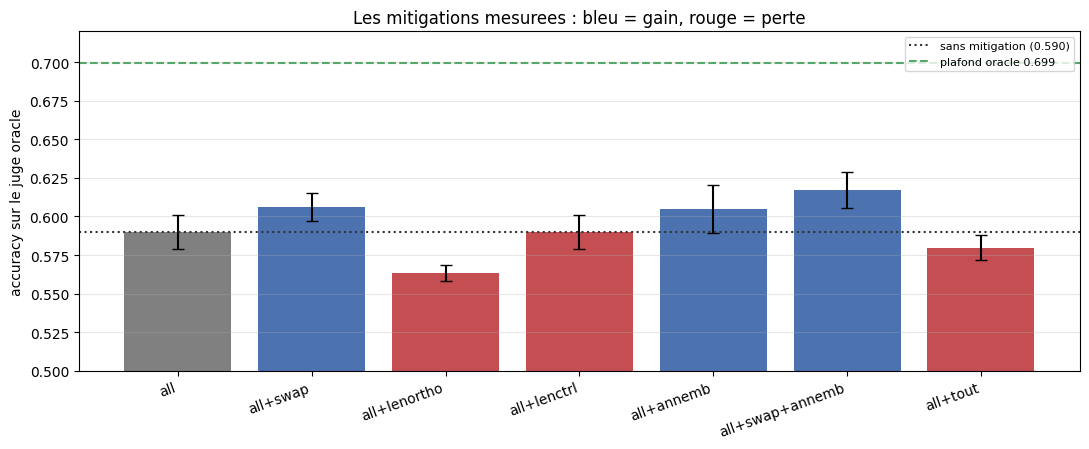

config                  acc_oracle    delta  gamma_len  scale
all                    0.590+-0.011   +0.000     +0.157   1.91
all+swap               0.606+-0.009   +0.016     +0.118   1.32
all+lenortho           0.563+-0.005   -0.027     +0.337   2.80
all+lenctrl            0.590+-0.011   +0.000     +0.157   1.91
all+annemb             0.605+-0.016   +0.015     +0.192   1.71
all+swap+annemb        0.617+-0.012   +0.027     +0.139   1.25
all+tout               0.580+-0.008   -0.010     +0.293   1.89

lenctrl, accuracy apres correction g*len : 0.587 (g pratique +0.166)


In [10]:
noms_m = ['all', 'all+swap', 'all+lenortho', 'all+lenctrl', 'all+annemb',
          'all+swap+annemb', 'all+tout']
fig, ax = plt.subplots(figsize=(11, 4.6))
base = RES['all']['acc_oracle']
xc = np.arange(len(noms_m))
vals = [RES[n]['acc_oracle'] for n in noms_m]
cols = ['#808080' if n == 'all' else ('#4c72b0' if RES[n]['acc_oracle'] > base
                                      else '#c44e52') for n in noms_m]
ax.bar(xc, vals, yerr=[RES[n]['acc_oracle_sd'] for n in noms_m], capsize=4, color=cols)
ax.axhline(base, ls=':', color='#333333', label=f'sans mitigation ({base:.3f})')
ax.axhline(bay, ls='--', color='#55a868', label=f'plafond oracle {bay:.3f}')
ax.set_xticks(xc); ax.set_xticklabels(noms_m, rotation=20, ha='right')
ax.set_ylim(0.5, 0.72); ax.set_ylabel('accuracy sur le juge oracle')
ax.set_title('Les mitigations mesurees : bleu = gain, rouge = perte')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"{'config':<18}{'acc_oracle':>16}{'delta':>9}{'gamma_len':>11}{'scale':>7}")
print(f"{'all':<18}{base:>10.3f}+-{RES['all']['acc_oracle_sd']:.3f}{0.0:>+9.3f}"
      f"{RES['all']['gamma_len']:>+11.3f}{RES['all']['scale']:>7.2f}")
for n in noms_m[1:]:
    r = RES[n]
    print(f"{n:<18}{r['acc_oracle']:>10.3f}+-{r['acc_oracle_sd']:.3f}"
          f"{r['acc_oracle'] - base:>+9.3f}{r['gamma_len']:>+11.3f}{r['scale']:>7.2f}")
print(f"\nlenctrl, accuracy apres correction g*len : "
      f"{RES['all+lenctrl']['acc_oracle_lc']:.3f} "
      f"(g pratique {RES['all+lenctrl']['g_corr']:+.3f})")

**Lecture du tableau.** C'est le résultat le moins confortable du notebook, et il faut
le donner tel quel : **aucune des trois mitigations du cahier des charges ne produit un
gain qui franchisse 2 écarts-types** sur le critère oracle. La seule qui franchisse ce
seuil est la quatrième — celle qui sert de contrôle — et elle **aggrave**.

Les écarts-types sont **propagés** depuis les écarts-types inter-seed de chaque
configuration ($\sigma_\Delta = \sqrt{\sigma_1^2 + \sigma_2^2}$). L'hypothèse
d'indépendance est **conservatrice** ici : les quatre seeds sont les mêmes d'une
configuration à l'autre, donc un appariement par seed réduirait la barre. Les rapports
ci-dessous sont donc un *minorant* de la significativité — si un effet ne franchit pas
2σ ici, il ne le franchit pas non plus avec un test apparié.

| Mitigation | Δ `acc_oracle` | σ propagé | Lecture |
|---|---|---|---|
| `swap` | **+0.016** | +1.1σ | le mieux placé, mais toujours sous le seuil. S'attaquer au biais de position en annulant son espérance est le seul levier qui vise un biais *représentable* dans les étiquettes. Effet net sur la structure : γ 0.157 → 0.118, échelle 1.91 → 1.32 — un score moins gonflé par la longueur |
| `annemb` | **+0.015** | +0.8σ | comparable à `swap`, et moins bien tenu : moyenner sur les têtes d'annotateurs ajoute de la variance (σ passe de 0.011 à 0.016), ce qui suffit à ramener le rapport sous 1σ |
| `swap+annemb` | **+0.027** | +1.7σ | la meilleure combinaison, la seule qui s'approche du seuil sans l'atteindre |
| `lenctrl` | **+0.000** | exactement 0 | nul **par construction** (cf. ci-dessus) : la correction multiplie $\Delta\hat r$ par un scalaire positif, elle ne change aucun ordre. Après correction explicite : 0.587, soit −0.003 |
| `lenortho` | **-0.027** | **-2.2σ** | **la seule mitigation à franchir 2σ — dans le mauvais sens.** $\gamma$ 0.157 → 0.337 (il double), échelle 1.91 → 2.80 |
| `tout` | **-0.010** | -0.7σ | sous la configuration sans mitigation, mais **pas significativement** |

Deux enseignements, tous deux contre-intuitifs.

**1. La mitigation la plus ambitieuse est la seule à produire un effet franc — et cet
effet est négatif.** `lenortho` a l'air d'attaquer le problème à la racine : rendre le
reward orthogonal à la longueur. En pratique, une pénalité dont le coefficient $g$ est
estimé sur le modèle *avant* correction se laisse défaire : le modèle ré-augmente son
propre coefficient de longueur de 0.157 à 0.337 pour compenser, et l'échelle grimpe à
2.80. Une pénalité mal ancrée ne supprime pas un raccourci, elle le **déplace**. C'est le
seul résultat de la série qui soit statistiquement solide — et il condamne la mitigation
la plus sophistiquée des quatre.

**2. Les points estimés s'additionnent, y compris celui de la mitigation nuisible.**
+0.027 (`swap+annemb`) -0.027 (`lenortho`) ≈ 0, et
c'est bien ce que l'on observe : la configuration « tout » retombe à
+0.580. Il faut résister à la surinterprétation : l'écart de
-0.010 contre la référence ne vaut que -0.7σ, donc
l'annulation est *cohérente avec* une addition simple, elle ne la démontre pas. Ce qui
est établi, c'est que rien dans cet empilement ne compose en synergie.

Le corollaire pratique : sur ce dispositif, aucune correction appliquée **après coup** ne
récupère le dégât. Un biais que le RM a internalisé dans son signal n'en est plus
séparable. Ce qu'il faut corriger est en amont, dans la collecte.

## Exercice 1 — le plafond de Bayes dépend du juge, pas du modèle

Écrire une fonction `plafond(lam, b, order)` qui, sur le jeu de test partagé,
retourne le plafond de Bayes du juge correspondant. Vérifier que le plafond **monte**
quand on ajoute du biais de position en collecte `fixed` : un juge plus biaisé est un
juge plus *prévisible*, donc plus facile à imiter. C'est le piège central du notebook
— un RM qui s'accorde à 80 % avec son juge peut être un très mauvais RM.

In [11]:
def plafond(lam, b, order='random'):
    """Plafond de Bayes du juge (lam, b) sur le jeu de test partage."""
    # Indice : reconstruire p_j = sigmoid(judge_logit(...)) sur m_te, puis
    #         retourner E[max(p_j, 1 - p_j)].
    # Etape 1 : recupérer pw_te, m_te = make_test(1000, 1000)
    # Etape 2 : le logit depend de l'ordre de collecte (order='fixed' -> avantage +b)
    # Etape 3 : moyenner max(p, 1-p)
    pass


# Decommenter apres avoir ecrit la fonction :
# for lam, b, o in [(0.0, 0.0, 'random'), (LAM_JEUGE, 0.0, 'random'),
#                   (0.0, 0.0, 'fixed'), (0.0, B_POS, 'fixed')]:
#     print(f'lam={lam:.2f} b={b:.2f} {o:>6} -> plafond {plafond(lam, b, o):.3f}')
print("Exercice a completer")

Exercice a completer


## Exercice 2 — un quatrième biais : le biais de style

Le biais de longueur est un biais de **forme**. Un autre biais classique est le biais
de **style** : le juge récompense un jeton qui n'a aucune valeur pour la tâche (par
exemple le jeton `d`, de poids vrai $+0.10$, que le juge surévalue à $+0.60$).

Ajouter un paramètre `bonus_style` à `judge_logit`, qui ajoute `bonus_style` au logit
chaque fois que la réponse contient le jeton `d`. Puis :

1. générer un dataset de train avec `bonus_style = 0.8` ;
2. mesurer `acc_oracle` et l'écart au plafond ;
3. comparer au dégât du biais de longueur à $\lambda = 0.25$ : lequel coûte le plus
   cher, et pourquoi ? (Indice : comparer la variance du logit parasite dans les deux
   cas — un bonus par *jeton* sur une longueur variable n'a pas la même variance qu'un
   bonus par *occurrence d'un jeton parmi huit*.)

In [12]:
def judge_logit_style(ra, rb, la, lb, lam, b, first_adv, a, bb, bonus_style):
    """Variante de judge_logit avec un bonus par occurrence du jeton 'd' (id 5)."""
    # Indice : compter les occurrences de V['d'] dans a et dans bb, et ajouter
    #          bonus_style * (n_d(a) - n_d(bb)) au logit.
    pass


print("Exercice a completer")

Exercice a completer


## Exercice 3 — le piège du score, la vraie métrique

Un reward model n'est pas jugé sur son accuracy mais sur ce qu'il fait faire à la
politique qui l'optimise. Écrire une fonction `optimiser_longueur(model, n_steps)`
qui, partant d'une politique uniforme sur les 8 jetons de contenu et de longueur
fixe $L = 8$, fait monter la longueur par montée de gradient sur le score du RM :
à chaque étape, échantillonner des réponses de longueurs croissantes et garder celles
que le RM préfère.

Question : le RM entraîné sur `all` pousse-t-il la politique vers des réponses
**plus longues** que le RM entraîné sur `ref` ? Mesurer la longueur moyenne choisie
dans les deux cas. C'est le pont direct vers `rlpt_3_reward_hacking` et le bloc A.3 :
un biais de longueur dans le RM devient une **course à la longueur** dans la
politique — le reward hacking n'est pas un accident, c'est la conséquence mécanique
d'un `acc_oracle` dégradé.

In [13]:
def optimiser_longueur(model, n_steps=60, L_fixe=8):
    """Longueur moyenne selectionnee par un RM soumis a une pression de longueur."""
    # Indice : pour chaque longueur L de LEN_MIN a LEN_MAX, tirer n echantillons
    #          de reponses aleatoires, les scorer avec score(model, pw, meta),
    #          et retourner la longueur de la meilleure.
    # Comparer 'ref' et 'all' : attendu, le RM biaise sur-selecte les longues.
    pass


print("Exercice a completer")

Exercice a completer


## Conclusion — ce qu'il faut retenir

**1. Le reward model recopie le juge qu'on lui donne.** Sur un monde où la longueur
ne porte pas d'information sur la qualité — le contrôle le vérifie cellule par cellule :
`corr(r*, len) = +0.0132`, soit une dépendance résiduelle de l'ordre de 4 % du
$\lambda$ que l'on injecte —, un juge qui ajoute $\lambda\,|y|$ produit un reward model
dont le coefficient de longueur mesuré vaut $\gamma \approx \lambda$ (+0.270 pour
$\lambda = 0.25$). Le RM n'échoue pas à résister au biais : il l'apprend, et c'est ce
qui le rend mauvais.

**2. L'accord au juge est la métrique qui ment — de deux façons.** Pour la longueur et
les annotateurs, ajouter le biais fait **monter** l'accord au juge biaisé (0.649 → 0.704
et 0.685) pendant que l'accord à l'oracle **descend** : une évaluation qui ne regarde que
le premier critère conclut à une amélioration. Le biais de position montre l'autre face
du piège : l'accord au juge y **chute** à 0.581 *alors même que le plafond de ce juge
monte à 0.789*. Le RM ne peut pas représenter un avantage constant de présentation, donc
il ne colle même pas au juge qu'on lui donne, et se contente de sous-échelonner le vrai
reward ($\beta_r$ = 0.57 contre 1.04). Dans les deux cas le plafond de Bayes du juge —
non pas 1.0 — est la seule référence honnête du premier critère, et il *faut* un second
critère, tenu à l'écart du biais.

**3. Les mitigations sont décevantes, et il faut le mesurer plutôt que le supposer.**
Dans cette expérience :

- **aucune ne franchit 2 écarts-types** sur le critère oracle. `swap`
  (+0.016, +1.1σ) et `annemb` (+0.015,
  +0.8σ) sont les deux mieux placées, et chacune reste **sous le
  seuil** : ce sont des tendances, pas des résultats. Leur combinaison vaut
  +0.027 (+1.7σ), la seule qui s'en approche ;
- `lenctrl` (correction post-hoc façon AlpacaEval) **ne peut pas** déplacer une
  accuracy de classement : elle multiplie $\Delta\hat r$ par un scalaire positif, ce qui
  ne change aucun ordre. La mitigation est saine pour ce qu'elle vise — le *taux de
  victoire* — et sans effet sur la métrique mesurée ici. Un Δ de 0.000 exactement, et
  pour une raison structurelle, pas empirique ;
- `lenortho` **aggrave** franchement : $\gamma$ double (0.157 → 0.337) et l'échelle du
  score passe de 1.91 à 2.80. Le modèle se ré-optimise autour de la pénalité et déplace
  le biais vers une autre représentation — c'est le seul effet ample et non bruité de
  la série, et il est négatif ;
- la conclusion la plus solide de la série est **négative** : `lenortho` est la seule
  mitigation à franchir le seuil de 2σ (-2.2σ), et elle aggrave. Les
  points estimés s'additionnent (+0.027 -0.027 ≈ 0,
  d'où « tout » à +0.580), mais l'écart de « tout » contre la référence ne
  vaut que -0.7σ : l'annulation est *cohérente avec* une addition, elle n'est
  pas démontrée. Ce qui l'est, c'est qu'aucun empilement ne compose en synergie.

**4. Le vrai remède est en amont du modèle.** Aucune correction appliquée après coup
à un reward model ne peut retirer un biais que le modèle a internalisé dans son
signal. Ce qu'il faut corriger, c'est la **collecte** : randomiser l'ordre de
présentation, contrôler la longueur dans l'échantillonnage des paires, modéliser les
annotateurs séparément. Le biais d'un dataset de préférences est un problème de
*donnée*, pas un problème de régularisation.

**Suite naturelle** : le bloc A.3 (`Reward-Hacking-Case-Study`) branche exactement ce
résultat sur une politique — un RM à $\gamma > 0$ pousse PPO à écrire plus long, et
l'on mesure la chute de qualité avec une métrique indépendante.